In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid", context="talk")

In [3]:
CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent
DATA_DIR = PARENT_DIR / "T04_preprocess"
print(CURRENT_DIR)
print(DATA_DIR)

c:\Users\admin\Coding\research\weld-ml\src\P02_data\T05_EA
c:\Users\admin\Coding\research\weld-ml\src\P02_data\T04_preprocess


In [4]:
filepath = os.path.join(
    DATA_DIR, "./S02/S02_residual_stress_imputed_20260104_114536.xlsx"
)
dfm = pd.read_excel(filepath)
dfm


,idx_excel_post,section,sample_no,location,R,W,D,sigma_x_post,FWHM_post,idx_excel_pre,sigma_x_pre,FWHM_pre,diff_sigma_x
0,4,AA5052,1,1,1400,60,10,13.0,2.55,2,-15.0,2.50,28.0
1,25,AA5052,2,1,1400,60,15,16.0,2.51,9,2.0,2.47,14.0
2,46,AA5052,3,1,1400,60,20,19.0,2.47,16,9.0,2.48,10.0
3,67,AA5052,4,1,1400,70,10,20.0,2.45,23,10.0,2.48,10.0
4,88,AA5052,5,1,1400,70,15,6.0,2.47,30,0.0,2.49,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,1050,Center,50,7,1600,70,15,2.0,2.45,0,0.0,0.00,2.0
1130,1071,Center,51,7,1600,70,20,2.0,2.45,0,0.0,0.00,2.0
1131,1092,Center,52,7,1600,80,10,5.0,2.54,0,0.0,0.00,5.0
1132,1113,Center,53,7,1600,80,15,1.0,2.41,0,0.0,0.00,1.0


In [5]:
# Melt
filt = dfm["section"].isin(["AA5052", "AA6061"])
dfm1 = dfm[filt].melt(
    id_vars=["sample_no", "section", "location"],
    value_vars=["sigma_x_pre", "sigma_x_post"],
    var_name="measurement",
    value_name="residual_stress",
)
dfm1["measurement"] = dfm1["measurement"].map(
    {"sigma_x_pre": "Pre-Weld", "sigma_x_post": "Post-Weld"}
)
display(dfm1.head())

filt = dfm["section"].isin(["Center"])
dfm2 = dfm[filt].melt(
    id_vars=["sample_no", "section", "location"],
    value_vars=["diff_sigma_x"],
    var_name="measurement",
    value_name="residual_stress",
)
dfm2["measurement"] = dfm2["measurement"].map({"diff_sigma_x": "Post-Weld"})
display(dfm2.head())

dfm_melted = pd.concat([dfm1, dfm2], ignore_index=True)
dfm_melted = dfm_melted.rename(
    columns={
        "measurement": "Measurement",
        "residual_stress": "Residual Stress",
        "section": "Section",
        "location": "Location"
    }
)

,sample_no,section,location,measurement,residual_stress
0,1,AA5052,1,Pre-Weld,-15.0
1,2,AA5052,1,Pre-Weld,2.0
2,3,AA5052,1,Pre-Weld,9.0
3,4,AA5052,1,Pre-Weld,10.0
4,5,AA5052,1,Pre-Weld,0.0


,sample_no,section,location,measurement,residual_stress
0,1,Center,1,Post-Weld,12.0
1,2,Center,1,Post-Weld,17.0
2,3,Center,1,Post-Weld,12.0
3,4,Center,1,Post-Weld,20.0
4,5,Center,1,Post-Weld,14.0


,Section,Measurement,Residual Stress
0,AA5052,Pre-Weld,-10.351053
1,AA5052,Post-Weld,14.005291
2,Center,Post-Weld,11.391584
3,AA6061,Pre-Weld,35.333783
4,AA6061,Post-Weld,19.648453


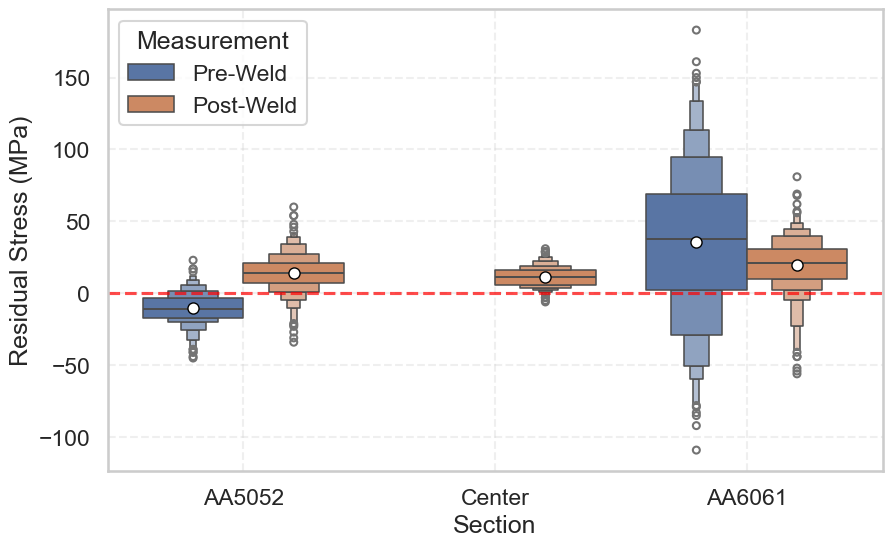

In [6]:
# filt = dfm_melted["Location"].isin([7])
filt = dfm_melted.index.notnull() # Include all rows
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxenplot(
    dfm_melted[filt],
    x="Section",
    y="Residual Stress",
    hue="Measurement",
    ax=ax,
    order=["AA5052", "Center", "AA6061"],
)
# Mean points
means = dfm_melted[filt].groupby(["Section", "Measurement"])["Residual Stress"].mean().reset_index()
means = means.loc[[1, 0, 4, 3, 2], :].reset_index(drop=True)  # Reorder the means DataFrame
display(means)
# Add the mean markers on top
spacer = 0.20  # Adjust this value to control the spacing of the mean markers
plt.plot(
    [0-spacer, 0+spacer, 1+spacer, 2-spacer, 2+spacer],
    means["Residual Stress"],
    "o",
    color="white",
    markeredgecolor="black",
    markeredgewidth=1,
    markersize=8,
    linestyle="none",
)
        
# Horizontal line at y=0
ax.axhline(0, color="red", linestyle="--", alpha=0.7)
ax.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.3,
)
ax.set_xlabel("Section")
ax.set_ylabel("Residual Stress (MPa)")
fig.savefig("residual_stress_by_section.png", dpi=300, bbox_inches="tight")
# ax.set_title("Pre-weld / Post-weld Residual Stress by Section")

In [7]:
# filt = dfm["section"].isin(["Center"])
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.boxenplot(dfm[filt], x="location", y="diff_sigma_x", ax=ax)
# ax.grid(True, which="major", linestyle="--", alpha=0.3)
# ax.set_title("Pre-weld / Post-weld Residual Stress by Section")

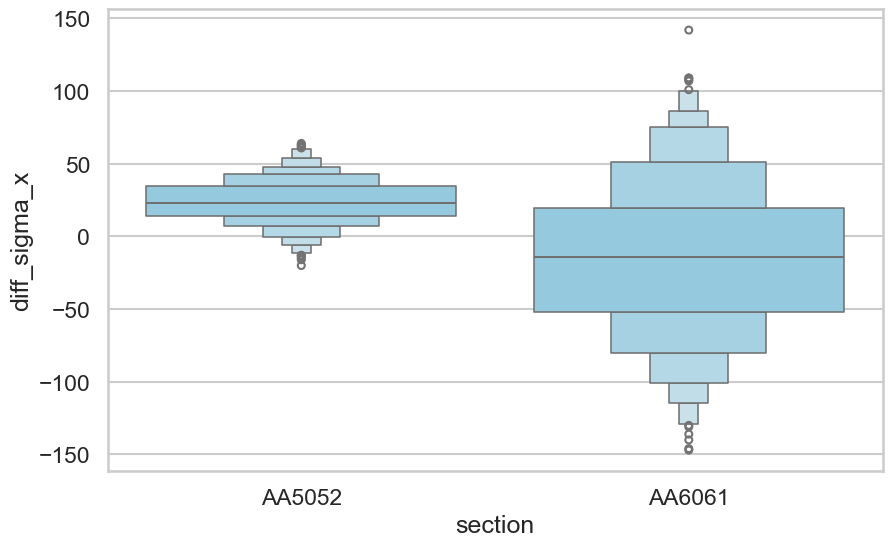

In [8]:
filt = dfm["section"].isin(["AA5052", "AA6061"])
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxenplot(
    dfm[filt],x="section", y="diff_sigma_x", ax=ax, order=["AA5052", "AA6061"], color="skyblue")
plt.show()